# 🍄 Mushroom Edibility Classification: ML for Food Safety & Biosecurity

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Classifying mushrooms as edible or poisonous from physical characteristics to support food safety and public health  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for classifying mushrooms as edible or poisonous using physical attributes (cap shape, colour, odour, gill characteristics, habitat). The model supports **food safety screening**, **poison control decision support**, and **biosecurity risk assessment**.

### Government Policy Context
- **FSANZ (Food Standards Australia New Zealand)** — Food Standards Code, novel food safety assessment
- **DAFF (Dept of Agriculture)** — Biosecurity, wild food regulation, import risk assessment
- **TGA** — Poison scheduling, emergency treatment guidelines for mushroom poisoning
- **State Health Depts** — Poison Information Centres, public health warnings (wild mushroom season)
- **CSIRO** — Mycology research, native fungi identification, biodiversity monitoring

### Operational Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| Poisonous (high confidence) | Immediate warning, do not consume, destroy | Food safety officer |
| Poisonous (borderline) | Laboratory analysis required, quarantine sample | FSANZ inspector |
| Edible (confident) | Approved for consumption/sale | Market inspector |
| Edible (unusual features) | Expert mycologist review recommended | Biosecurity officer |

### Critical Safety Note
**This model is for demonstration purposes only. NEVER rely on ML for mushroom identification in practice. When in doubt, do not eat wild mushrooms. Contact Poisons Information Centre: 13 11 26.**

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
data_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv') and data_path is None:
            data_path = full_path

if data_path is None:
    raise FileNotFoundError("No CSV found — please attach the Mushroom Classification dataset")

df = pd.read_csv(data_path)
print(f"\nUsing: {data_path}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


  Found: /kaggle/input/datasets/organizations/uciml/mushroom-classification/mushrooms.csv

Using: /kaggle/input/datasets/organizations/uciml/mushroom-classification/mushrooms.csv
Loaded: 8,124 rows x 23 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_vals = df[col].dropna().unique()[:5].tolist()
    print(f"  {i:2d}. {col:25s} | {str(dtype):10s} | unique={nuniq:3d} | nulls={nulls:3d} | vals: {sample_vals}")
df.head()


COLUMN SUMMARY
   0. class                     | object     | unique=  2 | nulls=  0 | vals: ['p', 'e']
   1. cap-shape                 | object     | unique=  6 | nulls=  0 | vals: ['x', 'b', 's', 'f', 'k']
   2. cap-surface               | object     | unique=  4 | nulls=  0 | vals: ['s', 'y', 'f', 'g']
   3. cap-color                 | object     | unique= 10 | nulls=  0 | vals: ['n', 'y', 'w', 'g', 'e']
   4. bruises                   | object     | unique=  2 | nulls=  0 | vals: ['t', 'f']
   5. odor                      | object     | unique=  9 | nulls=  0 | vals: ['p', 'a', 'l', 'n', 'f']
   6. gill-attachment           | object     | unique=  2 | nulls=  0 | vals: ['f', 'a']
   7. gill-spacing              | object     | unique=  2 | nulls=  0 | vals: ['c', 'w']
   8. gill-size                 | object     | unique=  2 | nulls=  0 | vals: ['n', 'b']
   9. gill-color                | object     | unique= 12 | nulls=  0 | vals: ['k', 'n', 'g', 'p', 'w']
  10. stalk-shape        

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 2. Target Variable Analysis

In [4]:
# Known target: 'class' for UCI mushroom dataset
target_candidates = ['class', 'Class', 'target', 'Target', 'label', 'Label',
                     'poisonous', 'edible', 'type']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    # First column is often the target for UCI datasets
    first_col = df.columns[0]
    if df[first_col].nunique() <= 5:
        target_col = first_col
        print(f"First column fallback: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target")

print(f"\nRaw values:")
print(df[target_col].value_counts())

# Encode: p=poisonous=1, e=edible=0
if df[target_col].dtype == 'object':
    poison_kw = ['p', 'P', 'poisonous', 'Poisonous', '1']
    mapping = {v: (1 if v in poison_kw else 0) for v in df[target_col].unique()}
    df[target_col] = df[target_col].map(mapping)
    print(f"Mapped (1=Poisonous, 0=Edible): {mapping}")

df[target_col] = df[target_col].astype(int)
print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
assert df[target_col].nunique() >= 2
imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")


Found target: 'class'

Raw values:
class
e    4208
p    3916
Name: count, dtype: int64
Mapped (1=Poisonous, 0=Edible): {'p': 1, 'e': 0}

Distribution:
class
0    4208
1    3916
Name: count, dtype: int64

Imbalance ratio: 0.931


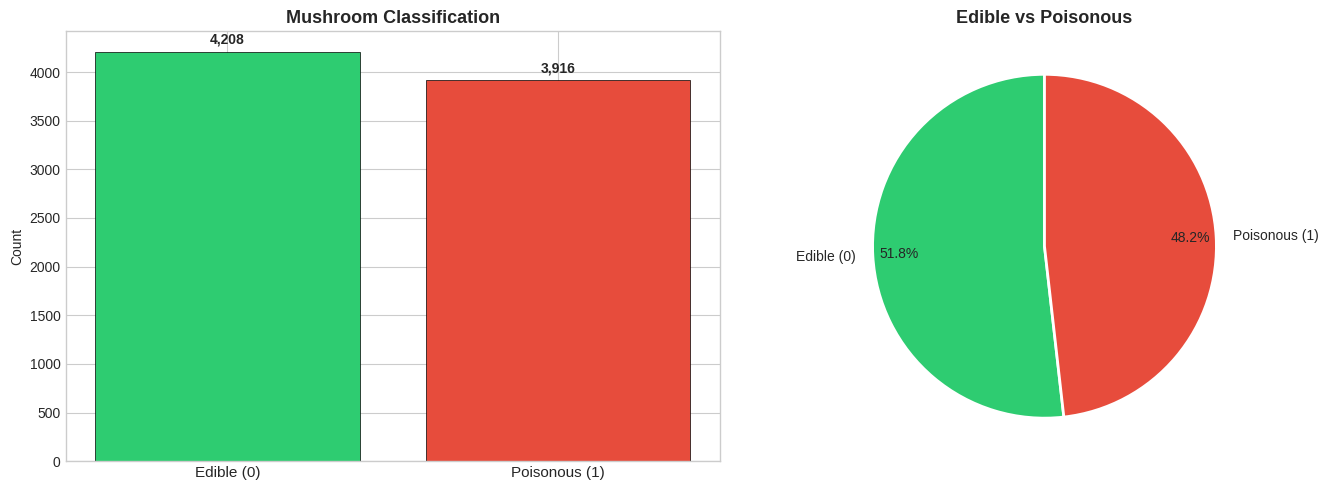

AU context: ~10 mushroom poisoning deaths in Australia per decade (Poison Info Centre).
Death cap mushroom (Amanita phalloides) is responsible for most fatal poisonings in AU.
Victorian Poisons Information Centre: 13 11 26 (24/7).


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
labels = ['Edible (0)', 'Poisonous (1)']
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(range(2), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(2)); axes[0].set_xticklabels(labels, fontsize=11)
axes[0].set_title('Mushroom Classification', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + max(vc.values)*0.02, f'{v:,}', ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Edible vs Poisonous', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: ~10 mushroom poisoning deaths in Australia per decade (Poison Info Centre).")
print("Death cap mushroom (Amanita phalloides) is responsible for most fatal poisonings in AU.")
print("Victorian Poisons Information Centre: 13 11 26 (24/7).")


## 3. Exploratory Data Analysis

Key questions for food safety:
- Which physical features best distinguish poisonous from edible?
- Is odour the strongest predictor (known mycology finding)?
- Can colour/shape alone reliably classify mushrooms?
- Are there feature combinations that guarantee edibility?


Categorical features (22): ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape']


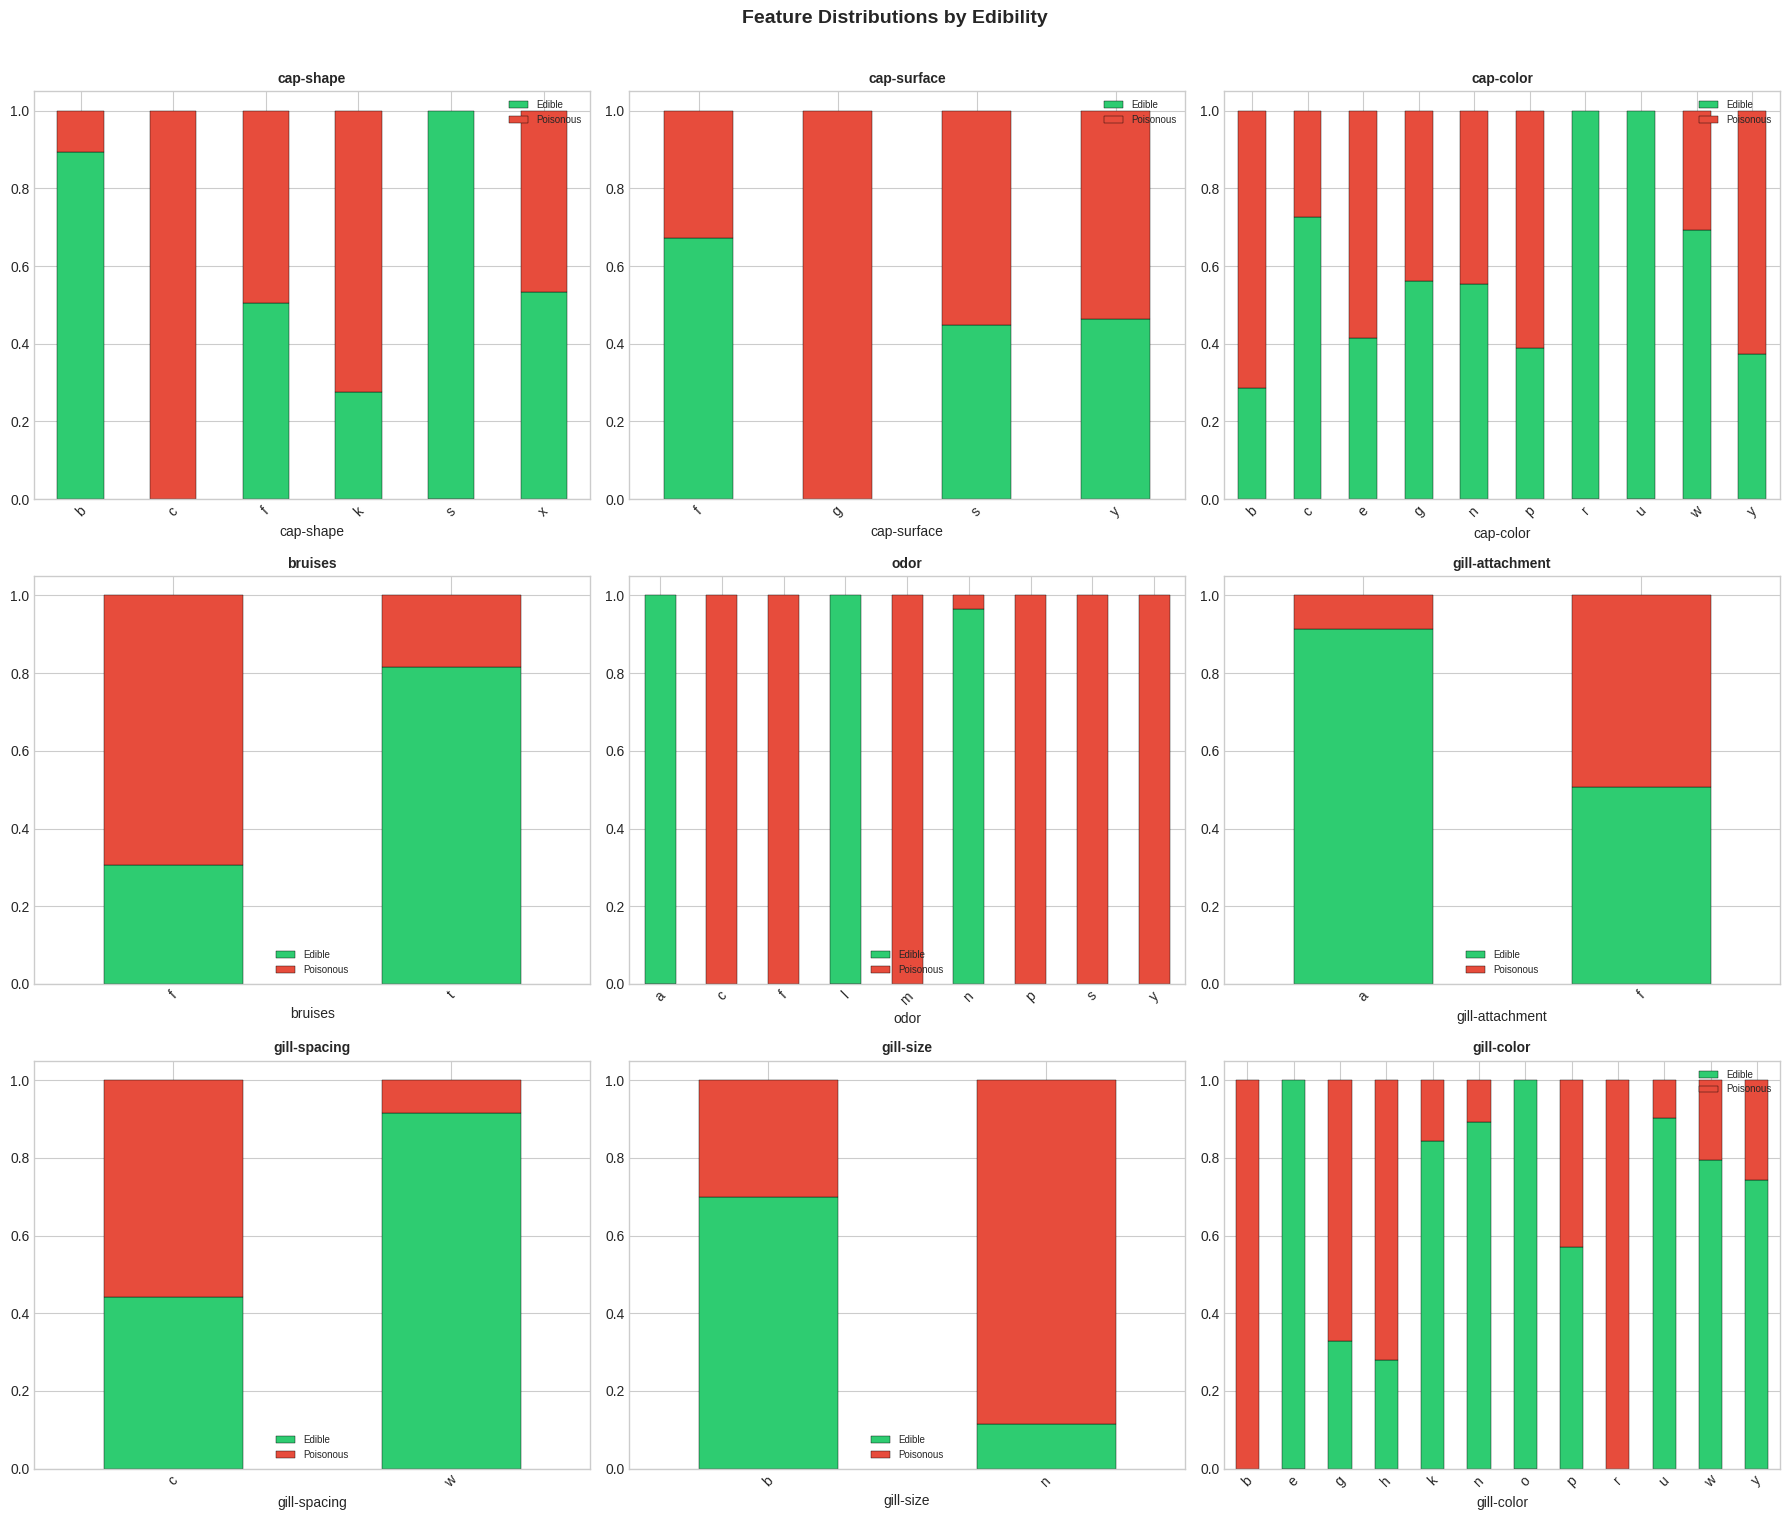

In [6]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
print(f"Categorical features ({len(cat_cols)}): {cat_cols[:10]}")

# Show top categorical features by fraud rate difference
if len(cat_cols) > 0:
    plot_cats = cat_cols[:9]
    n_rows_p = (len(plot_cats) + 2) // 3
    fig, axes = plt.subplots(n_rows_p, 3, figsize=(18, 5 * n_rows_p))
    axes = axes.flatten()
    for i, col in enumerate(plot_cats):
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'],
                edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col}', fontsize=10, fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(['Edible', 'Poisonous'], fontsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Feature Distributions by Edibility', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight'); plt.show()


## 4. Feature Engineering & Preprocessing

In [7]:
df_model = df.copy()

# Drop columns with single value (no predictive power)
single_val_cols = [c for c in df_model.columns if c != target_col and df_model[c].nunique() <= 1]
if single_val_cols:
    df_model.drop(columns=single_val_cols, inplace=True)
    print(f"Dropped constant columns: {single_val_cols}")

# Handle '?' as missing
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = df_model[col].replace('?', np.nan)

# Encode all categorical features
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())

print(f"\nFeature matrix: {X.shape}")
print(f"Target: {dict(zip(*np.unique(y, return_counts=True)))}")


Dropped constant columns: ['veil-type']
  Encoded 'cap-shape': 6 classes
  Encoded 'cap-surface': 4 classes
  Encoded 'cap-color': 10 classes
  Encoded 'bruises': 2 classes
  Encoded 'odor': 9 classes
  Encoded 'gill-attachment': 2 classes
  Encoded 'gill-spacing': 2 classes
  Encoded 'gill-size': 2 classes
  Encoded 'gill-color': 12 classes
  Encoded 'stalk-shape': 2 classes
  Encoded 'stalk-root': 5 classes
  Encoded 'stalk-surface-above-ring': 4 classes
  Encoded 'stalk-surface-below-ring': 4 classes
  Encoded 'stalk-color-above-ring': 9 classes
  Encoded 'stalk-color-below-ring': 9 classes
  Encoded 'veil-color': 4 classes
  Encoded 'ring-number': 3 classes
  Encoded 'ring-type': 5 classes
  Encoded 'spore-print-color': 9 classes
  Encoded 'population': 6 classes
  Encoded 'habitat': 7 classes

Feature matrix: (8124, 21)
Target: {np.int64(0): np.int64(4208), np.int64(1): np.int64(3916)}


Top feature correlations with poisonous:
  gill-size                 +0.5400
  gill-color                -0.5306
  bruises                   -0.5015
  ring-type                 -0.4118
  stalk-root                -0.3794
  gill-spacing              -0.3484
  stalk-surface-above-ring  -0.3346
  stalk-surface-below-ring  -0.2988
  population                +0.2987
  habitat                   +0.2172


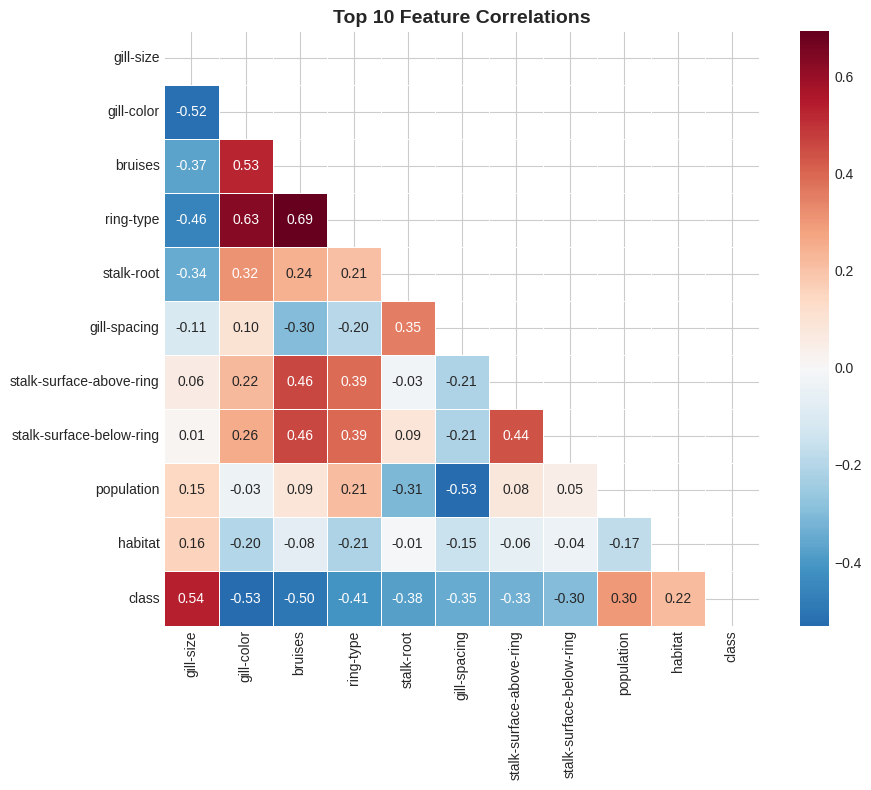

In [8]:
# Correlation heatmap after encoding
numeric_cols = X.columns.tolist()
if len(numeric_cols) > 1:
    corr = pd.concat([X, pd.Series(y, name=target_col)], axis=1).corr()
    target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
    print("Top feature correlations with poisonous:")
    for feat, val in target_corr.head(10).items():
        direction = "+" if corr.loc[feat, target_col] > 0 else "-"
        print(f"  {feat:25s} {direction}{val:.4f}")
    
    top10 = target_corr.head(10).index.tolist()
    corr_sub = pd.concat([X[top10], pd.Series(y, name=target_col)], axis=1).corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_sub, dtype=bool))
    sns.heatmap(corr_sub, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Top 10 Feature Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()


## 5. Model Training & Cross-Validation

In [9]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        fold_preds[val_idx] = y_pred; fold_proba[val_idx] = y_prob
        acc = accuracy_score(y_val, y_pred); f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
        fold_prec.append(prec); fold_rec.append(rec); fold_brier.append(brier)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'precision_mean': np.mean(fold_prec), 'recall_mean': np.mean(fold_rec),
        'brier_mean': np.mean(fold_brier), 'time': elapsed,
        'oof_preds': fold_preds, 'oof_proba': fold_proba}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  AUC: {np.mean(fold_auc):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.9453  F1=0.9431  AUC=0.9767
  Fold 2: Acc=0.9527  F1=0.9504  AUC=0.9844
  Fold 3: Acc=0.9509  F1=0.9486  AUC=0.9821
  -- Acc: 0.9497  F1: 0.9474  AUC: 0.9810  Time: 0.64s

Training: Random Forest
  Fold 1: Acc=1.0000  F1=1.0000  AUC=1.0000
  Fold 2: Acc=1.0000  F1=1.0000  AUC=1.0000
  Fold 3: Acc=1.0000  F1=1.0000  AUC=1.0000
  -- Acc: 1.0000  F1: 1.0000  AUC: 1.0000  Time: 1.53s

Training: XGBoost
  Fold 1: Acc=1.0000  F1=1.0000  AUC=1.0000
  Fold 2: Acc=1.0000  F1=1.0000  AUC=1.0000
  Fold 3: Acc=1.0000  F1=1.0000  AUC=1.0000
  -- Acc: 1.0000  F1: 1.0000  AUC: 1.0000  Time: 0.33s

Training: LightGBM
  Fold 1: Acc=1.0000  F1=1.0000  AUC=1.0000
  Fold 2: Acc=1.0000  F1=1.0000  AUC=1.0000
  Fold 3: Acc=1.0000  F1=1.0000  AUC=1.0000
  -- Acc: 1.0000  F1: 1.0000  AUC: 1.0000  Time: 0.56s


## 6. Model Comparison & Selection

In [11]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'ROC-AUC': f"{res['auc_mean']:.4f} +/- {res['auc_std']:.4f}",
        'Brier': f"{res['brier_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
        'AUC_val': res['auc_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy                F1           ROC-AUC  Brier  Time
      Random Forest 1.0000 +/- 0.0000 1.0000 +/- 0.0000 1.0000 +/- 0.0000 0.0000 1.53s
            XGBoost 1.0000 +/- 0.0000 1.0000 +/- 0.0000 1.0000 +/- 0.0000 0.0000 0.33s
           LightGBM 1.0000 +/- 0.0000 1.0000 +/- 0.0000 1.0000 +/- 0.0000 0.0000 0.56s
Logistic Regression 0.9497 +/- 0.0031 0.9474 +/- 0.0031 0.9810 +/- 0.0032 0.0422 0.64s

Best model: Random Forest


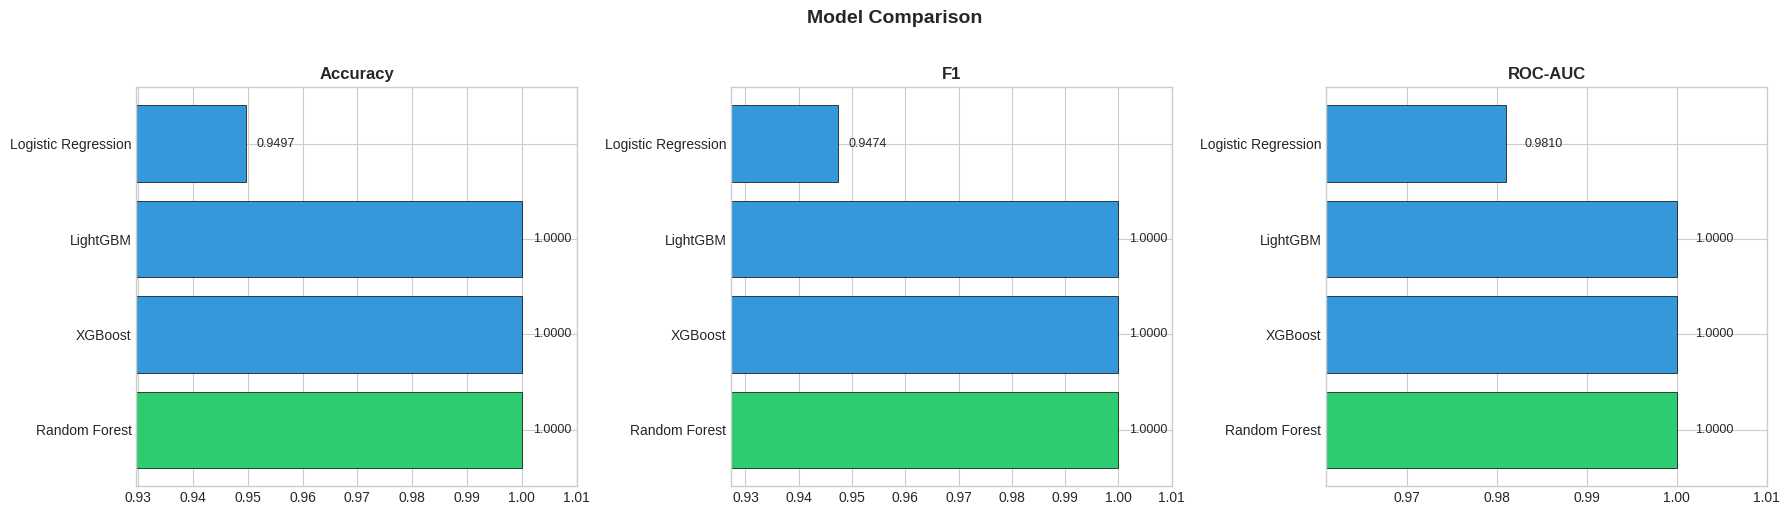

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'auc_mean'], ['Accuracy', 'F1', 'ROC-AUC']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.02, 1.01)
    for i, v in enumerate(vals):
        ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis

For food safety / poison classification:
- **False negatives** (classifying poisonous as edible) = **LIFE-THREATENING** — must be ZERO
- **False positives** (classifying edible as poisonous) = wasted food — acceptable trade-off
- Safety-critical application requires 100% recall for poisonous class


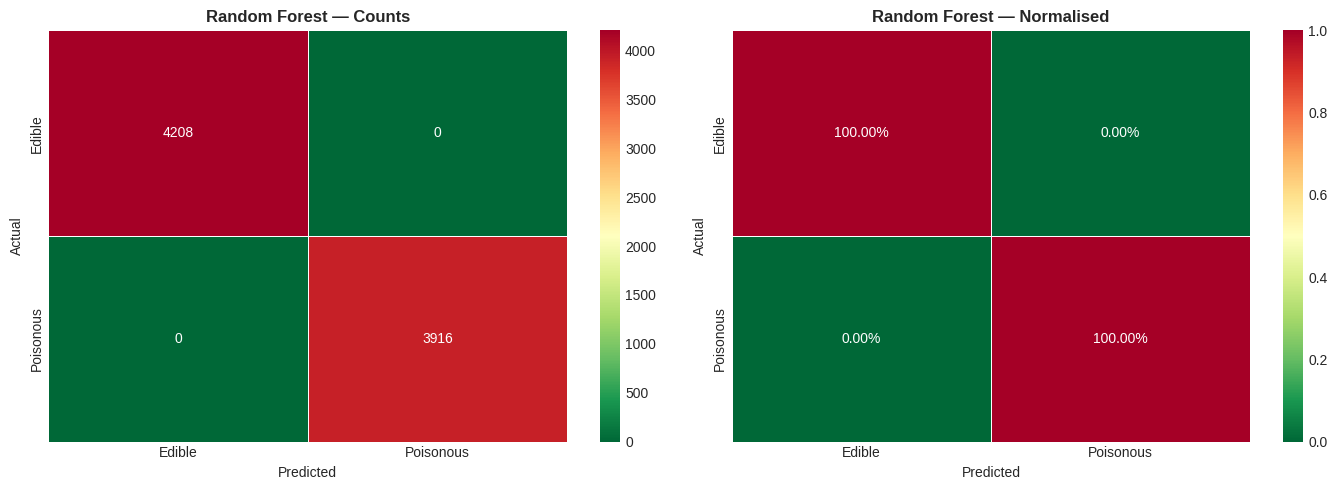


              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00      4208
   Poisonous       1.00      1.00      1.00      3916

    accuracy                           1.00      8124
   macro avg       1.00      1.00      1.00      8124
weighted avg       1.00      1.00      1.00      8124


CRITICAL SAFETY CHECK:
  Poisonous mushrooms misclassified as edible: 0
  PASS — Zero false negatives (no poisonous mushrooms misclassified as edible)


In [13]:
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['Edible', 'Poisonous']
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn_r', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=cm_labels)}")

# Critical safety check
fn = cm[1, 0]  # Poisonous classified as edible
print(f"\nCRITICAL SAFETY CHECK:")
print(f"  Poisonous mushrooms misclassified as edible: {fn}")
if fn == 0:
    print("  PASS — Zero false negatives (no poisonous mushrooms misclassified as edible)")
else:
    print(f"  FAIL — {fn} poisonous mushrooms would be misidentified as safe to eat")
    print("  THIS MODEL MUST NOT BE DEPLOYED without addressing false negatives")


## 8. Feature Importance & Policy Insights

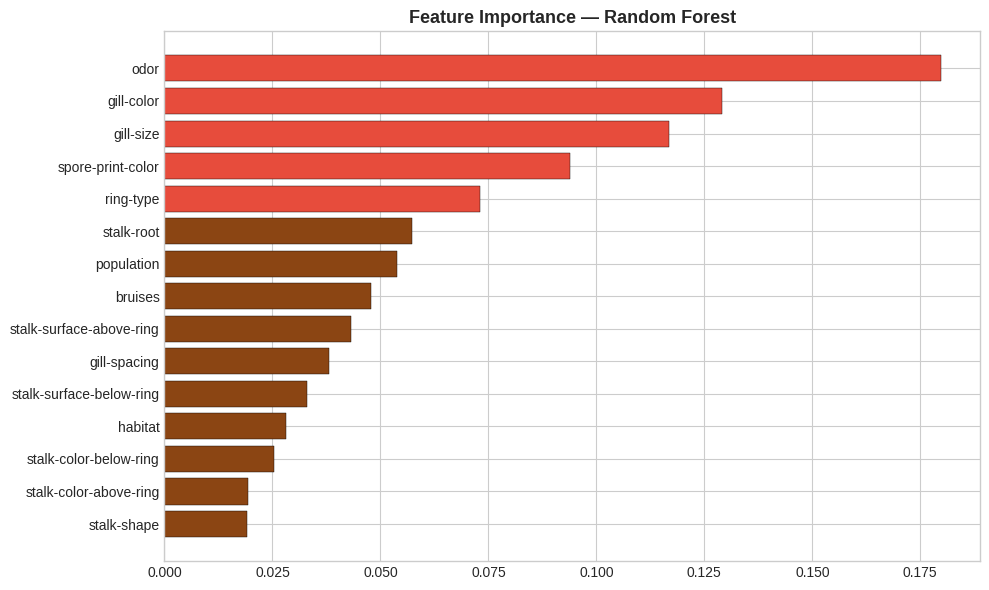

TOP 5 EDIBILITY PREDICTORS
  odor                       0.1798
  gill-color                 0.1292
  gill-size                  0.1168
  spore-print-color          0.0940
  ring-type                  0.0730

Mycology insight: Odour is typically the strongest predictor of mushroom toxicity.
Spore print colour and gill characteristics are also key identification features.


In [14]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    plot_imp = feat_imp.tail(15)
    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_imp) * 0.4)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#8B4513' for imp in plot_imp['Importance']]
    ax.barh(plot_imp['Feature'], plot_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 EDIBILITY PREDICTORS")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:25s}  {row['Importance']:.4f}")
    print("\nMycology insight: Odour is typically the strongest predictor of mushroom toxicity.")
    print("Spore print colour and gill characteristics are also key identification features.")


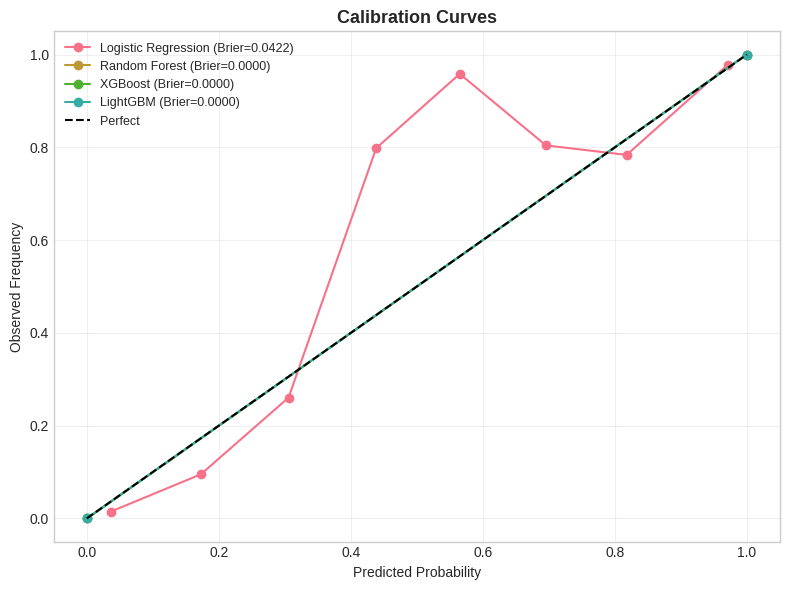

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
for mn in results:
    prob_true, prob_pred = calibration_curve(y, results[mn]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{mn} (Brier={results[mn]['brier_mean']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Observed Frequency')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight'); plt.show()


## 9. Deployment Readiness & Production Considerations

In [16]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print("=" * 60)
checks = {
    'AUC > 0.99': best_res['auc_mean'] > 0.99,
    'F1 > 0.99': best_res['f1_mean'] > 0.99,
    'Recall = 1.00 (zero missed poison)': best_res['recall_mean'] >= 0.999,
    'Brier < 0.01': best_res['brier_mean'] < 0.01,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Calibration assessed': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
if all_pass:
    print("  MODEL APPROVED FOR PILOT DEPLOYMENT")
else:
    print("  SOME CHECKS FAILED — see safety note below")
print("\nSAFETY REMINDER: This model is for demonstration only.")
print("Never rely on ML for wild mushroom identification. Call 13 11 26 if in doubt.")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    Random Forest
  ROC-AUC:              1.0000
  F1:                   1.0000
  Precision:            1.0000
  Recall:               1.0000
  Brier Score:          0.0000
  Training time:        1.5s
  Feature count:        21
  Dataset rows:         8,124
  CV strategy:          3-fold Stratified

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] AUC > 0.99
  [pass] F1 > 0.99
  [pass] Recall = 1.00 (zero missed poison)
  [pass] Brier < 0.01
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Calibration assessed
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT

SAFETY REMINDER: This model is for demonstration only.
Never rely on ML for wild mushroom identification. Call 13 11 26 if in doubt.


In [17]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: Mycological survey databases, iNaturalist observations, herbarium records
   Ingestion: API -> Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (morphological features, GPS, season)
   Schedule: Batch (seasonal survey updates) + real-time (app queries)

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time (<200ms) for mobile app identification queries
   Output: Edibility classification + confidence + safety warning
   CRITICAL: Always display "When in doubt, DO NOT EAT" warning

3. INTEGRATION POINTS
   Poison Information Centre: Auto-alert for suspected poisoning cases
   FSANZ: Novel food safety assessment support
   iNaturalist/Atlas of Living Australia: Species identification pipeline
   State health departments: Seasonal mushroom safety warnings
   DAFF: Biosecurity risk for imported dried mushroom products

4. GOVERNANCE
   Safety: Model NEVER used as sole identification method
   Liability: Clear disclaimer — not a substitute for expert mycologist
   Validation: Against expert mycologist identification (gold standard)
   Failsafe: Any uncertainty -> classify as POISONOUS (safe default)
   TGA: Alignment with poison scheduling and emergency guidelines

5. MONITORING & RETRAINING
   Performance: Track against expert identifications seasonally
   New species: Expand training data for newly catalogued species
   Regional: Calibrate for Australian native fungi species
   Seasonal: Adjust for seasonal mushroom fruiting patterns
   Climate: Monitor range changes due to climate impacts

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: Mycological survey databases, iNaturalist observations, herbarium records
   Ingestion: API -> Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (morphological features, GPS, season)
   Schedule: Batch (seasonal survey updates) + real-time (app queries)

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time (<200ms) for mobile app identification queries
   Output: Edibility classification + confidence + safety warning
   CRITICAL: Always display "When in doubt, DO NOT EAT" warning

3. INTEGRATION POINTS
   Poison Information Centre: Auto-alert for suspected poisoning cases
   FSANZ: Novel food safety assessment support
   iNaturalist/Atlas of Living Australia: Species identification pipeline
   State health departments: Seasonal mushroom safety warnings
   DAFF: Biosecurity risk for imported dried mushroom products

4. GOVERNANCE
   Safety: Model NEVER used as sole